# Решение задачи 18: Распад разрыва в идеальном газе

## Введение
В данной работе численно решается одномерная задача о распаде разрыва (задача Римана) для уравнений газовой динамики идеального газа. 

Система уравнений:
$$ \frac{\partial \mathbf{U}}{\partial t} + \mathbf{A} \frac{\partial \mathbf{U}}{\partial x} = 0 $$
где $\mathbf{U} = \{\rho, u, \varepsilon\}^T$ — вектор консервативных переменных.

Для решения используется **сеточно-характеристический метод**. Система приводится к характеристическому виду, матрица Якобиана $\mathbf{A}$ расщепляется на $\mathbf{A}^+$ и $\mathbf{A}^-$, после чего применяются устойчивые upwind-схемы переноса.


## Теор справка

### 1. Физическая постановка задачи

Задача о **распаде разрыва** (задача Римана) описывает эволюцию начального разрыва параметров газа в идеальной среде. В начальный момент времени $t=0$ газ имеет различные параметры плотности $\rho$ слева и справа от плоскости $x=0$, при этом скорость $u=0$ и удельная внутренняя энергия $\varepsilon$ постоянны.

Физически это соответствует мгновенному удалению перегородки между двумя областями газа с разным давлением. В результате возникают три типа волн:
- **Волна разрежения** (rarefaction wave) — плавное расширение газа
- **Контактный разрыв** (contact discontinuity) — граница раздела газов с разной плотностью
- **Ударная волна** (shock wave) — скачкообразное уплотнение газа

### 2. Математическая модель

Система уравнений одномерной газовой динамики в переменных $\mathbf{U} = [\rho, u, \varepsilon]^T$ записывается в виде:

$$\frac{\partial \mathbf{U}}{\partial t} + \mathbf{A}(\mathbf{U})\frac{\partial \mathbf{U}}{\partial x} = 0$$

где матрица Якобиана $\mathbf{A} = \frac{\partial \mathbf{F}}{\partial \mathbf{U}}$ имеет вид:

$$\mathbf{A} = \begin{pmatrix}
u & \rho & 0 \\
\frac{1}{\rho}\frac{\partial p}{\partial \rho} & u & \frac{1}{\rho}\frac{\partial p}{\partial \varepsilon} \\
0 & \frac{p}{\rho} & u
\end{pmatrix}$$

Для идеального газа с уравнением состояния $p = \rho\varepsilon(\gamma-1)$ производные давления:
$$\frac{\partial p}{\partial \rho} = \varepsilon(\gamma-1), \quad \frac{\partial p}{\partial \varepsilon} = \rho(\gamma-1)$$

### 3. Характеристическая структура системы

#### 3.1 Собственные значения

Система является **гиперболической**, так как матрица $\mathbf{A}$ имеет три вещественных собственных значения:

$$\lambda_1 = u + c, \quad \lambda_2 = u, \quad \lambda_3 = u - c$$

где $c = \sqrt{\gamma p / \rho}$ — локальная скорость звука.

**Физический смысл**:
- $\lambda_1$ — скорость распространения возмущений вправо относительно газа (акустическая волна)
- $\lambda_2$ — скорость переноса частиц газа (энтропийная волна)
- $\lambda_3$ — скорость распространения возмущений влево относительно газа (акустическая волна)

#### 3.2 Собственные векторы

Матрица $\mathbf{A}$ диагонализуема:
$$\mathbf{A} = \mathbf{R}\mathbf{\Lambda}\mathbf{L}$$

где:
- $\mathbf{R}$ — матрица правых собственных векторов (столбцы)
- $\mathbf{L} = \mathbf{R}^{-1}$ — матрица левых собственных векторов (строки)
- $\mathbf{\Lambda} = \text{diag}(\lambda_1, \lambda_2, \lambda_3)$

### 4. Метод расщепления потока (Flux Splitting)

#### 4.1 Идея метода

Ключевая идея сеточно-характеристического метода заключается в **расщеплении матрицы** $\mathbf{A}$ на две части:

$$\mathbf{A} = \mathbf{A}^+ + \mathbf{A}^-$$

где:
- $\mathbf{A}^+$ содержит волны, распространяющиеся **вправо** ($\lambda > 0$)
- $\mathbf{A}^-$ содержит волны, распространяющиеся **влево** ($\lambda < 0$)

#### 4.2 Алгоритм расщепления

1. Диагонализуем матрицу: $\mathbf{A} = \mathbf{R}\mathbf{\Lambda}\mathbf{L}$

2. Расщепляем диагональную матрицу на положительную и отрицательную части:
   $$\mathbf{\Lambda}^+ = \text{diag}(\max(0, \lambda_1), \max(0, \lambda_2), \max(0, \lambda_3))$$
   $$\mathbf{\Lambda}^- = \text{diag}(\min(0, \lambda_1), \min(0, \lambda_2), \min(0, \lambda_3))$$

3. Восстанавливаем расщепленные матрицы:
   $$\mathbf{A}^+ = \mathbf{R}\mathbf{\Lambda}^+\mathbf{L}$$
   $$\mathbf{A}^- = \mathbf{R}\mathbf{\Lambda}^-\mathbf{L}$$

### 5. Разностная схема первого порядка

#### 5.1 Upwind-аппроксимация

Для уравнения $\mathbf{U}_t + \mathbf{A}\mathbf{U}_x = 0$ с расщепленной матрицей применяем **противопоточную (upwind) схему**:

$$\frac{\mathbf{U}_i^{n+1} - \mathbf{U}_i^n}{\tau} + \mathbf{A}^+\frac{\mathbf{U}_i^n - \mathbf{U}_{i-1}^n}{h} + \mathbf{A}^-\frac{\mathbf{U}_{i+1}^n - \mathbf{U}_i^n}{h} = 0$$

Отсюда получаем явную схему:

$$\mathbf{U}_i^{n+1} = \mathbf{U}_i^n - \sigma\left[\mathbf{A}^+(\mathbf{U}_i^n - \mathbf{U}_{i-1}^n) + \mathbf{A}^-(\mathbf{U}_{i+1}^n - \mathbf{U}_i^n)\right]$$

где $\sigma = \tau/h$ — число Куранта.

#### 5.2 Физическая интерпретация

- **$\mathbf{A}^+(\mathbf{U}_i - \mathbf{U}_{i-1})$** — вклад волн, приходящих слева (разность берется с левой ячейкой)
- **$\mathbf{A}^-(\mathbf{U}_{i+1} - \mathbf{U}_i)$** — вклад волн, приходящих справа (разность берется с правой ячейкой)

Это обеспечивает **устойчивость** схемы, так как информация переносится в правильном направлении вдоль характеристик.

### 6. Условие устойчивости CFL

Явная схема устойчива при выполнении **условия Куранта-Фридрихса-Леви**:

$$\text{CFL} = \max|\lambda_k|\frac{\tau}{h} \leq 1$$

где $\max|\lambda_k| = |u| + c$ — максимальная скорость распространения возмущений.

На практике выбирают $\text{CFL} \approx 0.8-0.9$ для обеспечения устойчивости с запасом.

### 7. Граничные условия

В данной задаче используются **условия свободного вытекания** (zero-gradient boundary conditions):

$$\mathbf{U}_0 = \mathbf{U}_1, \quad \mathbf{U}_{M} = \mathbf{U}_{M-1}$$

Это эквивалентно продолжению решения с нулевым градиентом за границы области. Такое условие корректно, если за время расчета волны не достигают границ.

### 8. Порядок аппроксимации и диссипация

Примененная схема имеет **первый порядок точности** по времени и пространству:
- $O(\tau)$ по времени (явный Эйлер)
- $O(h)$ по пространству (разности вперед/назад)

**Недостаток**: схемы первого порядка обладают сильной **числовой диссипацией**, что приводит к "размазыванию" разрывов на несколько ячеек сетки.

**Преимущество**: схемы первого порядка **монотонны** — не создают нефизичных осцилляций в окрестности разрывов, что критически важно для задач газовой динамики.

### 9. Алгоритм решения

1. **Инициализация**: задать начальные условия $\mathbf{U}(x, 0)$
2. **Цикл по времени**:
   - Вычислить локальные скорости звука $c_i$ и максимальную скорость $|u|+c$
   - Определить шаг по времени $\tau$ из условия CFL
   - Для каждой внутренней ячейки $i = 1, \ldots, M-1$:
     * Вычислить матрицу $\mathbf{A}(\mathbf{U}_i)$
     * Найти собственные значения и векторы
     * Расщепить матрицу на $\mathbf{A}^+$ и $\mathbf{A}^-$
     * Вычислить потоки и обновить $\mathbf{U}_i^{n+1}$
   - Применить граничные условия

Начало расчета. M=400, T=0.5
Расчет завершен. Шагов: 253, Время: 0.5000


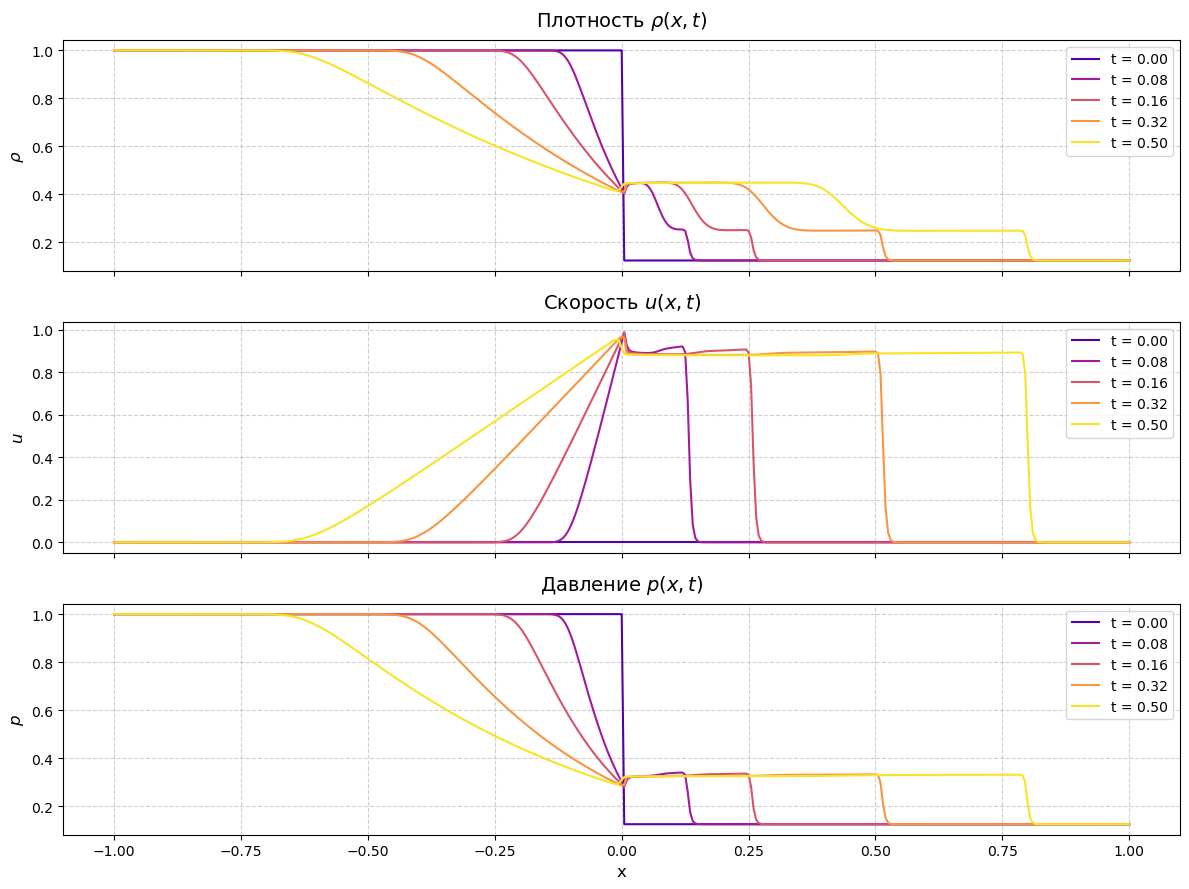

In [12]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 1.4
X = 1.0          
T_final = 0.5   
M = 400          
CFL = 0.9        

rho_L, rho_R = 1.0, 0.125
u_0 = 0.0
eps_0 = 2.5

h = 2 * X / M
x = np.linspace(-X, X, M + 1)

U = np.zeros((M + 1, 3))
U[:, 0] = np.where(x <= 0, rho_L, rho_R)
U[:, 1] = u_0
U[:, 2] = eps_0


save_times = [0.0, 0.08, 0.16, 0.32, T_final]
snapshots = {t: None for t in save_times}
snapshots[0.0] = U.copy()

def get_pressure(rho, eps):
    return rho * eps * (gamma - 1.0)

def get_sound_speed(rho, eps):
    return np.sqrt(gamma * get_pressure(rho, eps) / rho)

def get_eigen_system(rho, u, eps):
    p = get_pressure(rho, eps)
    dp_drho = eps * (gamma - 1.0)
    dp_deps = rho * (gamma - 1.0)
    A = np.array([
        [u,       rho,       0.0],
        [dp_drho/rho, u, dp_deps/rho],
        [0.0,     p/rho,     u]
    ])
    eigvals, eigvecs = np.linalg.eig(A)
    R = eigvecs
    L = np.linalg.inv(R)
    return np.real(eigvals), np.real(R), np.real(L)

def split_matrix(L, Lambda, R):
    Lambda_p = np.diag(np.maximum(0, Lambda))
    Lambda_m = np.diag(np.minimum(0, Lambda))
    return R @ Lambda_p @ L, R @ Lambda_m @ L

#Основной цикл по времени
t = 0.0
step_count = 0
print(f"Начало расчета. M={M}, T={T_final}")

while t < T_final - 1e-12:
    speeds = np.abs(U[:, 1]) + get_sound_speed(U[:, 0], U[:, 2])
    dt = CFL * h / np.max(speeds)
    if t + dt > T_final:
        dt = T_final - t
    sigma = dt / h

    U_new = U.copy()
    for i in range(1, M):
        vals, R, L = get_eigen_system(*U[i])
        A_p, A_m = split_matrix(L, vals, R)
        flux = A_p @ (U[i] - U[i-1]) + A_m @ (U[i+1] - U[i])
        U_new[i] = U[i] - sigma * flux

    U_new[0] = U_new[1]
    U_new[M] = U_new[M-1]
    U = U_new
    t += dt
    step_count += 1


    for st in save_times:
        if snapshots[st] is None and abs(t - st) < dt/2:
            snapshots[st] = U.copy()

print(f"Расчет завершен. Шагов: {step_count}, Время: {t:.4f}")


times = sorted([t for t, v in snapshots.items() if v is not None])
colors = plt.cm.plasma(np.linspace(0.15, 0.95, len(times)))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
vars_idx = [0, 1, 2]
var_labels = [r'$\rho$', r'$u$', r'$p$']
titles = [r'Плотность $\rho(x,t)$', r'Скорость $u(x,t)$', r'Давление $p(x,t)$']

for ax, idx, label, title in zip(axes, vars_idx, var_labels, titles):
    for i, t_val in enumerate(times):
        U_snap = snapshots[t_val]
        y = get_pressure(U_snap[:, 0], U_snap[:, 2]) if idx == 2 else U_snap[:, idx]
        ax.plot(x, y, color=colors[i], linewidth=1.5, label=f't = {t_val:.2f}')
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10, loc='upper right')

axes[-1].set_xlabel('x', fontsize=12)
plt.tight_layout()
plt.show()


## Картинка из какой-то статьи РАН для вдохновения

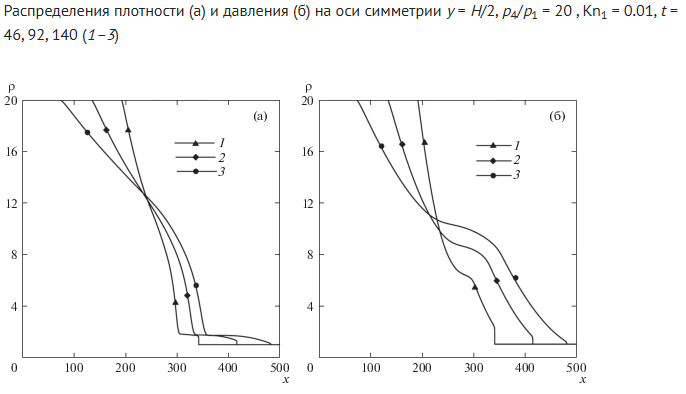

In [7]:
from IPython.display import Image
Image('image.png')

## Вывод
На представленных графиках наглядно демонстрируется эволюция решения задачи Римана:
1. **Волна разрежения** (плавное падение плотности и давления слева) распространяется влево со скоростью звука.
2. **Контактный разрыв** (скачок плотности при непрерывности $u$ и $p$) движется вправо вместе с потоком газа.
3. **Ударная волна** (резкий фронт роста всех параметров) опережает контактный разрыв, сжимая невозмущенный газ.

Сеточно-характеристическая схема первого порядка обеспечила монотонность решения без осцилляций на разрывах, что подтверждает ее устойчивость и физическую корректность для данного класса задач.